In [3]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.figure_factory as ff

from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("../data/Reviews.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [6]:
missing = df.isnull().sum()

missing

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [8]:
rating_counts = df["Score"].value_counts().sort_index()

fig = px.bar(
    x=rating_counts.index,
    y=rating_counts.values,
    color=rating_counts.index.astype(str),
    text=rating_counts.values,
    title="Amazon Review Rating Distribution",
    labels={
        "x":"Rating",
        "y":"Number of Reviews"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

In [10]:
def sentiment(score):

    if score <=2:
        return "Negative"

    elif score==3:
        return "Neutral"

    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(sentiment)

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive


In [11]:
sentiment_counts = df["Sentiment"].value_counts()

fig = px.bar(
    sentiment_counts,
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    color=sentiment_counts.index,
    text=sentiment_counts.values,
    title="Sentiment Distribution"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

print(sentiment_counts)

Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


In [12]:
df["Review_Length"] = df["Text"].apply(len)

df["Review_Length"].describe()

count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: Review_Length, dtype: float64

In [17]:
fig = px.histogram(
    df,
    x="Review_Length",
    nbins=60,
    title="Distribution of Review Length"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

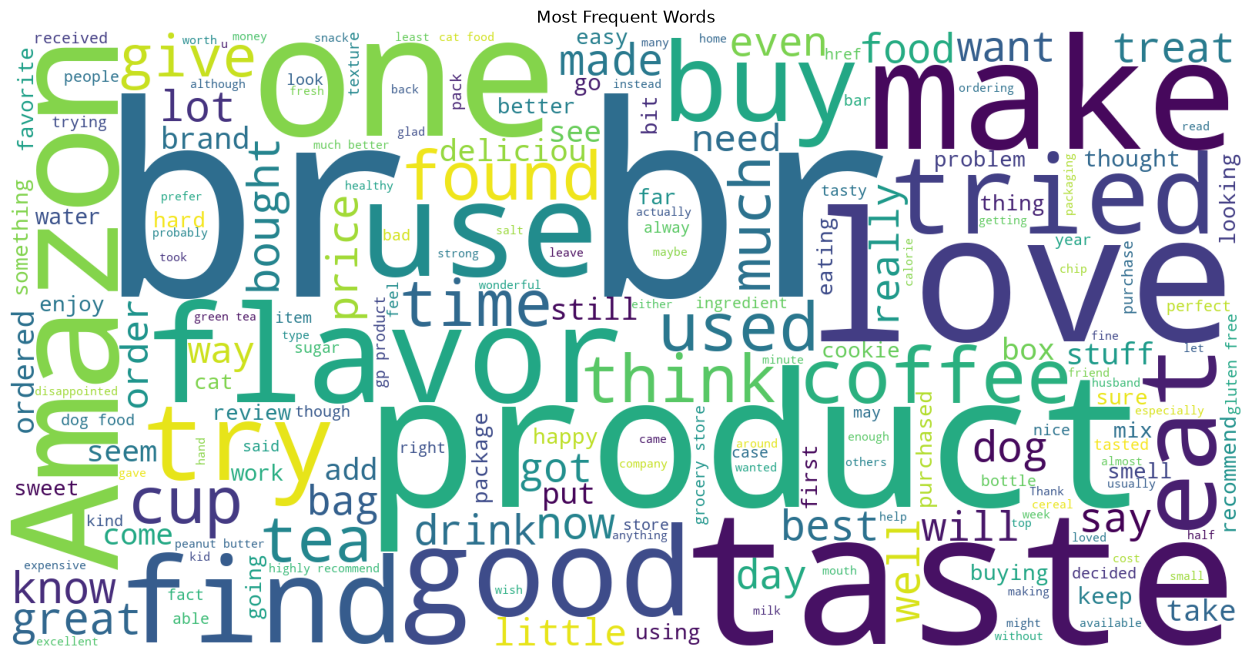

In [15]:
text = " ".join(df["Text"].astype(str))

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white"
).generate(text)

plt.figure(figsize=(18,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words")

plt.show()

In [16]:
df.to_csv("../data/processed_reviews.csv", index=False)

print("Processed Dataset Saved Successfully!")

Processed Dataset Saved Successfully!
